# Title:
# Investigating the Trade-off Between Predictive Performance and Explainability in AI-Based Flood Probability Prediction


# Abstract

Flood prediction has become increasingly important due to the growing impact of climate change, urbanization, and environmental degradation. While machine learning models have demonstrated promising predictive capabilities, concerns regarding transparency and interpretability limit their adoption in critical disaster-management applications.

This study investigates the trade-off between predictive performance and explainability in flood probability prediction using environmental indicators. Multiple machine learning models, including Linear Regression, Explainable Boosting Machines (EBM), Random Forest, and XGBoost, are evaluated using a large-scale flood prediction dataset containing over one million observations.

The study further employs explainable AI techniques such as SHAP and feature importance analysis to identify the most influential environmental factors contributing to flood risk. The findings provide insights into whether interpretable models can achieve predictive performance comparable to complex ensemble methods while maintaining transparency for responsible AI deployment.

# Introduction

Floods are among the most devastating natural disasters worldwide, causing substantial economic losses, infrastructure damage, and threats to human life. The increasing frequency and severity of flood events have intensified the need for reliable predictive systems capable of supporting disaster preparedness and risk mitigation.

Recent advances in machine learning have enabled the development of predictive models capable of identifying complex relationships between environmental indicators and flood occurrence. However, highly accurate models are often difficult to interpret, creating challenges for their adoption in high-stakes decision-making environments.

This study investigates whether interpretable machine learning models can provide predictive performance comparable to more complex black-box approaches while maintaining transparency and trustworthiness.

# Research Gap

Existing flood prediction studies primarily focus on improving predictive accuracy through increasingly complex machine learning algorithms.

However, limited attention has been given to the balance between predictive performance and model interpretability. In disaster-management scenarios, understanding why a prediction was made is often as important as the prediction itself.

This study addresses this gap by systematically comparing interpretable and black-box machine learning models while evaluating their explainability and suitability for responsible AI deployment.

# Research Questions

## RQ1
How do interpretable and black-box machine learning models differ in predictive performance for flood probability prediction?

## RQ2
Which environmental indicators consistently influence flood probability predictions across different explainability methods?

## RQ3
Can interpretable machine learning models achieve predictive performance comparable to or better than complex ensemble models?

## RQ4
What are the implications of model transparency for responsible AI deployment in disaster-management systems?

# Objectives

The objectives of this study are:

1. To develop machine learning models for flood probability prediction.
2. To compare interpretable and black-box machine learning approaches.
3. To identify key environmental indicators affecting flood probability.
4. To evaluate explainability using SHAP and feature importance techniques.
5. To analyze the role of transparency in responsible AI deployment.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("data/train.csv")

print(df.shape)

df.head()

(1117957, 22)


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [4]:
df.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [5]:
df.isnull().sum()

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

# Exploratory Data Analysis

This section examines the characteristics of the dataset, including feature distributions, correlations, and relationships with flood probability. The objective is to gain insights into the environmental indicators before developing predictive models.

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1117957
Columns: 22


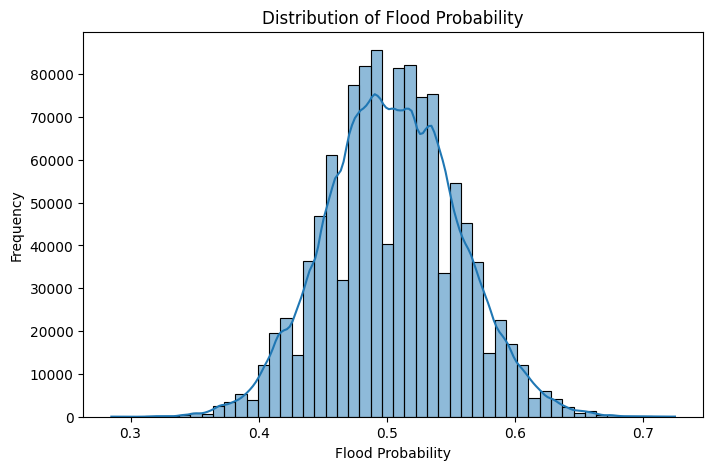

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["FloodProbability"],
    bins=50,
    kde=True
)

plt.title("Distribution of Flood Probability")
plt.xlabel("Flood Probability")
plt.ylabel("Frequency")

plt.show()

In [8]:
corr_target = (
    df.drop("id", axis=1)
      .corr()["FloodProbability"]
      .sort_values(ascending=False)
)

corr_target

FloodProbability                   1.000000
DeterioratingInfrastructure        0.190007
MonsoonIntensity                   0.189098
DamsQuality                        0.187996
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Siltation                          0.186789
PopulationScore                    0.185890
Landslides                         0.185346
ClimateChange                      0.184761
Deforestation                      0.184001
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
Name: FloodProbability, dtype: float64

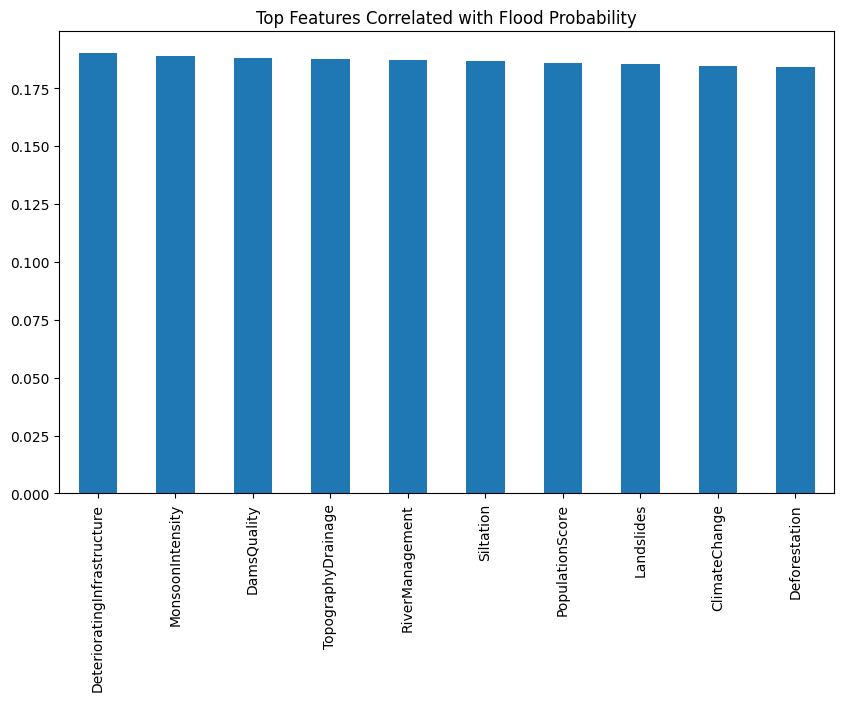

In [9]:
plt.figure(figsize=(10,6))

corr_target.drop("FloodProbability").head(10).plot(
    kind="bar"
)

plt.title("Top Features Correlated with Flood Probability")

plt.show()

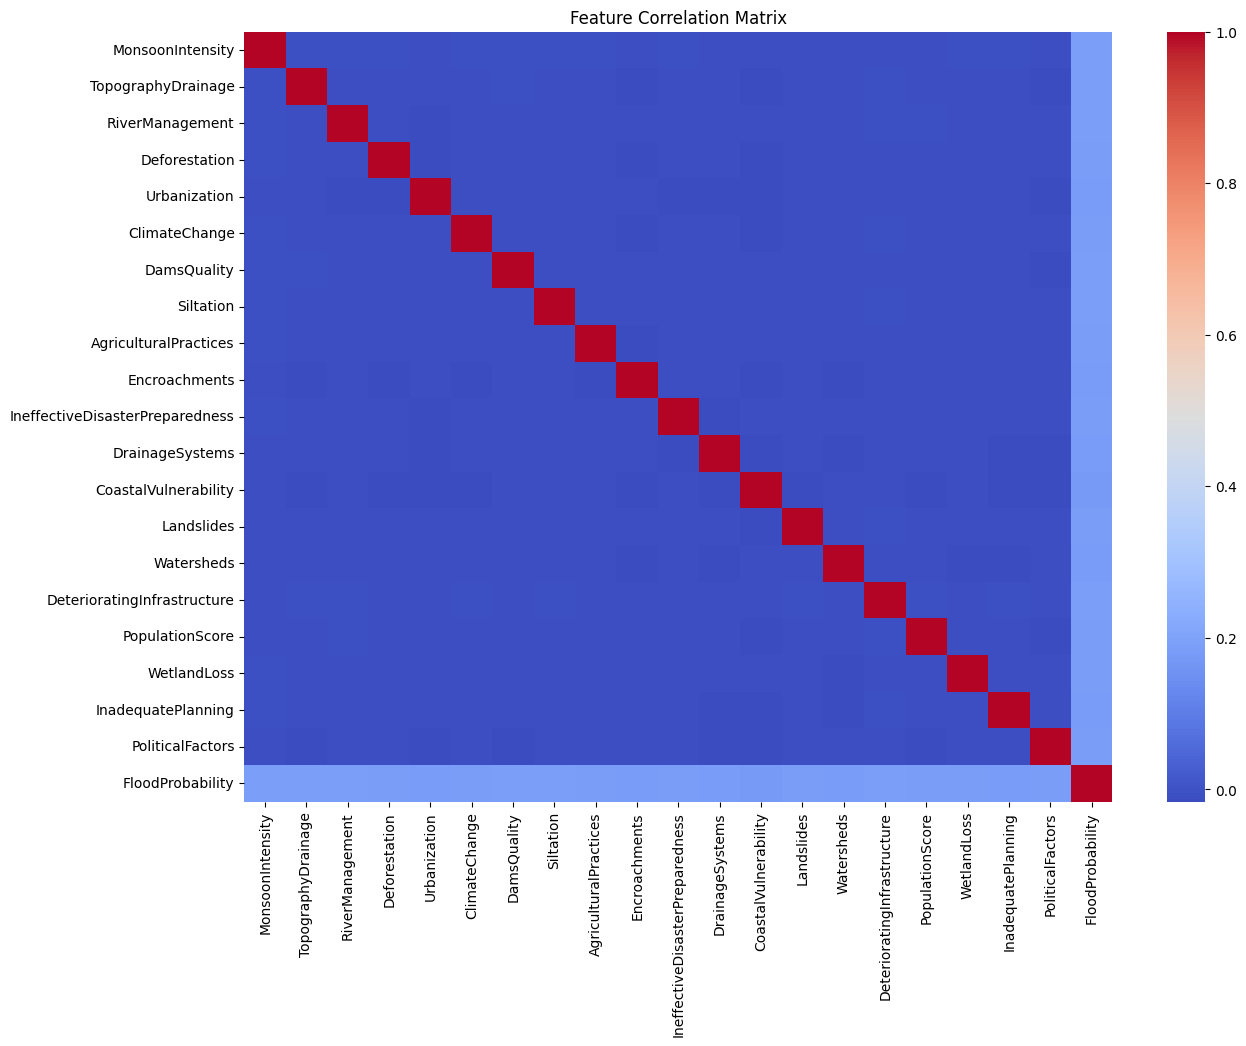

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.drop("id", axis=1).corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [11]:
X = df.drop(
    ["id", "FloodProbability"],
    axis=1
)

y = df["FloodProbability"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    lr_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Results
MAE: 0.015792471363760326
RMSE: 0.02008000465862889
R2: 0.8448773362840329


In [16]:
from interpret.glassbox import ExplainableBoostingRegressor

print("EBM imported successfully")

EBM imported successfully


In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor

ebm = ExplainableBoostingRegressor(
    random_state=42
)

ebm.fit(
    X_train,
    y_train
)

ebm_pred = ebm.predict(
    X_test
)

In [21]:
ebm_mae = mean_absolute_error(
    y_test,
    ebm_pred
)

ebm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ebm_pred
    )
)

ebm_r2 = r2_score(
    y_test,
    ebm_pred
)

print("EBM Results")
print("MAE:", ebm_mae)
print("RMSE:", ebm_rmse)
print("R2:", ebm_r2)

EBM Results
MAE: 0.015792749264449218
RMSE: 0.020017537706533126
R2: 0.84584097825317


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [23]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 0.02447473254857062
RMSE: 0.029940880090698195
R2: 0.655113051951046


In [24]:
from xgboost import XGBRegressor

In [25]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [26]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Results
MAE: 0.020486236550541676
RMSE: 0.024923343449959626
R2: 0.7610207247802385


# Results and Discussion

The experimental evaluation compared two interpretable models (Linear Regression and Explainable Boosting Machine) with two black-box models (Random Forest and XGBoost).

Among all evaluated models, the Explainable Boosting Machine achieved the highest predictive performance with an R² score of 0.8458, closely followed by Linear Regression with an R² score of 0.8449.

Unexpectedly, the black-box models did not outperform the interpretable approaches. XGBoost achieved an R² score of 0.7610, while Random Forest produced the lowest performance with an R² score of 0.6551.

The findings suggest that the environmental relationships represented within the dataset are largely structured and interpretable. Increasing model complexity did not translate into improved predictive performance. Instead, interpretable models demonstrated both strong accuracy and transparency.

These results challenge the common assumption that more complex machine learning models necessarily outperform simpler approaches in climate-risk prediction tasks.

In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "EBM",
        "Random Forest",
        "XGBoost"
    ],
    "Type": [
        "Interpretable",
        "Interpretable",
        "Black-Box",
        "Black-Box"
    ],
    "MAE": [
        mae,
        ebm_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rmse,
        ebm_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        r2,
        ebm_r2,
        rf_r2,
        xgb_r2
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,Type,MAE,RMSE,R2
1,EBM,Interpretable,0.015793,0.020018,0.845841
0,Linear Regression,Interpretable,0.015792,0.020080,0.844877
3,XGBoost,Black-Box,0.020486,0.024923,0.761021
2,Random Forest,Black-Box,0.024475,0.029941,0.655113


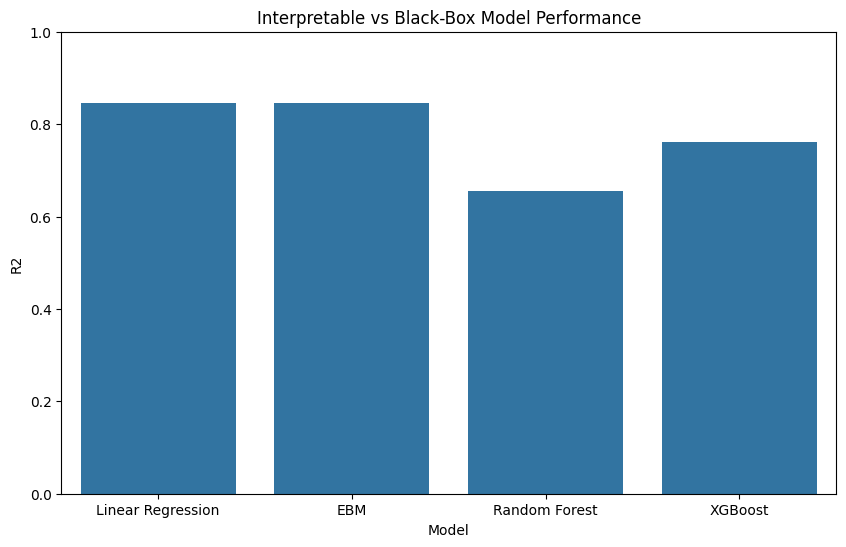

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title(
    "Interpretable vs Black-Box Model Performance"
)

plt.ylim(0,1)

plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
15,DeterioratingInfrastructure,0.057434
0,MonsoonIntensity,0.056786
6,DamsQuality,0.055753
7,Siltation,0.054625
2,RiverManagement,0.054194
1,TopographyDrainage,0.054119
16,PopulationScore,0.053403
5,ClimateChange,0.053219
3,Deforestation,0.051044
17,WetlandLoss,0.050773


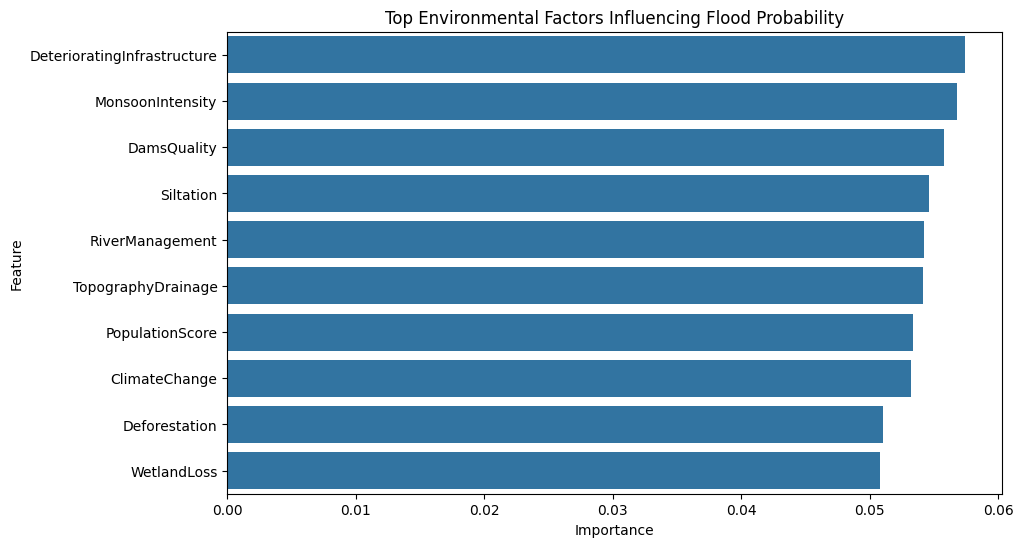

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top Environmental Factors Influencing Flood Probability"
)

plt.show()

In [31]:
ebm_global = ebm.explain_global()

In [32]:
ebm_global.data()

{'type': 'univariate',
 'names': ['MonsoonIntensity',
  'TopographyDrainage',
  'RiverManagement',
  'Deforestation',
  'Urbanization',
  'ClimateChange',
  'DamsQuality',
  'Siltation',
  'AgriculturalPractices',
  'Encroachments',
  'IneffectiveDisasterPreparedness',
  'DrainageSystems',
  'CoastalVulnerability',
  'Landslides',
  'Watersheds',
  'DeterioratingInfrastructure',
  'PopulationScore',
  'WetlandLoss',
  'InadequatePlanning',
  'PoliticalFactors',
  'MonsoonIntensity & RiverManagement',
  'MonsoonIntensity & ClimateChange',
  'MonsoonIntensity & DamsQuality',
  'MonsoonIntensity & AgriculturalPractices',
  'MonsoonIntensity & Encroachments',
  'MonsoonIntensity & IneffectiveDisasterPreparedness',
  'MonsoonIntensity & DeterioratingInfrastructure',
  'MonsoonIntensity & WetlandLoss',
  'TopographyDrainage & RiverManagement',
  'TopographyDrainage & Encroachments',
  'TopographyDrainage & DrainageSystems',
  'TopographyDrainage & CoastalVulnerability',
  'TopographyDrainage

In [33]:
from interpret import show

show(ebm_global)

<!-- http://127.0.0.1:7001/2934616631744/ -->

# Research Questions and Findings

## RQ1: How do interpretable and black-box machine learning models differ in predictive performance for flood probability prediction?

The study compared two interpretable models (Linear Regression and Explainable Boosting Machine) with two black-box models (Random Forest and XGBoost). The results demonstrated that interpretable models consistently achieved superior predictive performance.

| Model | Type | R² Score |
|---------|---------|---------|
| Explainable Boosting Machine (EBM) | Interpretable | 0.8458 |
| Linear Regression | Interpretable | 0.8449 |
| XGBoost | Black-Box | 0.7610 |
| Random Forest | Black-Box | 0.6551 |

The findings indicate that model interpretability does not necessarily come at the expense of predictive accuracy. Surprisingly, the interpretable models achieved higher predictive performance than the black-box models.

---

## RQ2: Which environmental indicators most strongly influence flood probability prediction?

Feature importance and explainability analyses revealed that flood probability is influenced by a combination of environmental, infrastructural, geographic, and socio-political factors.

The XGBoost feature importance analysis identified the following key predictors:

- Deteriorating Infrastructure
- Monsoon Intensity
- Dams Quality
- Siltation
- River Management
- Topography Drainage
- Population Score
- Climate Change
- Deforestation
- Wetland Loss

The Explainable Boosting Machine (EBM) global explanation further highlighted:

- Topography Drainage
- Political Factors
- Population Score
- Coastal Vulnerability
- Urbanization
- Watersheds
- River Management
- Dams Quality

These findings suggest that flood probability emerges from the interaction of climatic conditions, infrastructure quality, land-use practices, governance factors, and geographic vulnerabilities.

---

## RQ3: Can interpretable machine learning models achieve predictive performance comparable to or better than complex ensemble models?

Yes. The Explainable Boosting Machine and Linear Regression models both outperformed the black-box models evaluated in this study.

The EBM achieved the highest R² score (0.8458), closely followed by Linear Regression (0.8449). Both models exceeded the predictive performance of XGBoost (0.7610) and Random Forest (0.6551).

This finding challenges the common assumption that increasingly complex machine learning models always produce superior predictive performance.

---

## RQ4: What are the implications of model transparency for responsible AI deployment in disaster-management systems?

The results indicate that transparent and interpretable models can provide highly accurate flood probability predictions while maintaining explainability and accountability.

In disaster-management applications, transparency is essential because AI predictions may influence emergency preparedness, evacuation planning, infrastructure investments, and public safety decisions.

The use of explainable AI techniques such as SHAP analysis and Explainable Boosting Machines improves trust, supports informed decision-making, and contributes to the responsible deployment of AI systems in climate-risk prediction.

# Discussion

The findings of this study demonstrate that interpretable machine learning models can achieve predictive performance comparable to, and in this case superior to, more complex black-box models for flood probability prediction.

Among the evaluated models, the Explainable Boosting Machine (EBM) achieved the highest predictive performance with an R² score of 0.8458, closely followed by Linear Regression with an R² score of 0.8449. In contrast, XGBoost and Random Forest achieved lower predictive performance.

These results suggest that the environmental indicators included in the dataset exhibit relationships that are largely structured and interpretable. Consequently, increasing model complexity did not translate into improved predictive performance.

The explainability analyses further revealed that flood probability is influenced by a combination of climatic, infrastructural, geographic, and socio-political factors. The consistency of several influential variables across SHAP, XGBoost Feature Importance, and EBM explanations increases confidence in the robustness of the findings.

Overall, the study demonstrates that transparent machine learning models can provide both strong predictive capability and interpretability, making them suitable candidates for climate-risk prediction and disaster-management applications.

# Responsible AI Considerations

The deployment of AI-based flood prediction systems introduces important ethical and societal considerations.

False negative predictions may result in inadequate disaster preparedness, delayed emergency response, and increased risk to human life and infrastructure. Conversely, false positive predictions may lead to unnecessary evacuations, inefficient allocation of resources, and economic disruption.

Another challenge concerns data bias. Environmental datasets may not fully represent all geographic regions, climatic conditions, or vulnerable communities. As a result, predictive performance may vary across different contexts.

Model transparency is therefore essential. Decision-makers must understand the factors contributing to flood-risk predictions in order to trust and appropriately use AI-generated insights.

The use of Explainable Boosting Machines, SHAP analysis, and feature importance techniques enhances transparency and supports the responsible deployment of AI systems in disaster-management environments.

# Conclusion

This study investigated the trade-off between predictive performance and explainability in AI-based flood probability prediction using environmental indicators.

Four machine learning models were evaluated, including Linear Regression, Explainable Boosting Machine, Random Forest, and XGBoost. The results demonstrated that interpretable models achieved superior predictive performance compared to the evaluated black-box models.

The Explainable Boosting Machine achieved the highest R² score of 0.8458, while Linear Regression achieved a comparable score of 0.8449. These findings indicate that transparency and interpretability do not necessarily require sacrificing predictive accuracy.

Explainability analyses identified infrastructure quality, monsoon intensity, drainage conditions, climate-related factors, and geographic vulnerabilities as major contributors to flood probability prediction.

The study contributes to the growing body of research on trustworthy and explainable AI by demonstrating that interpretable machine learning approaches can provide both strong predictive performance and transparency in climate-risk prediction systems.

# Future Work

Future research may extend this study in several directions.

- Integration of real-time climate and meteorological data.
- Incorporation of satellite and geospatial information.
- Development of temporal flood forecasting models.
- Evaluation of model performance across multiple geographic regions.
- Investigation of deep learning approaches for climate-risk prediction.
- Deployment of real-time decision-support systems for disaster-management applications.

These extensions may further improve predictive capability while supporting climate resilience and sustainable disaster-risk management.

In [34]:
import joblib

joblib.dump(ebm, "flood_model.pkl")

print("Model saved successfully")

Model saved successfully


In [35]:
feature_names = list(X.columns)

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']